# Prioriza CG

## Escopo da Pesquisa

- Problema: distância entre o que a população pensa e observa e o que é feito pelo Governo.
- Objetivo: escutar as demandas e perspectivas da população de Campo Grande, MS.
- Método de coleta: [via formulário Google](https://forms.gle/iHF6zabZxLoy2iaS6)


## Perguntas

### Perguntas pessoais

1. Qual é o seu melhor email?
2. Qual é o número do seu WhatsApp?
3. Qual é o bairro que você mora?

### Perguntas do escopo

4. Você acredita que a **população** pode ter uma **participação efetiva** nas 3 esferas de governança (Executivo, Legislativo e Judiciário)?
5. Quais **áreas sociais** você acredita que têm sido mais **esquecidas**, e que por consequência, tem tido mais **problemas** em nossa cidade nos **últimos 4 anos**? (Pode selecionar mais de um)
6. Das **áreas sociais** selecionadas, quais são os **maiores problemas** **atualmente**?
7. Com vistas aos problemas pontuados, quais seriam as **maiores prioridades** para os **próximos 4 anos** por **área social** selecionada?
8. Quais **sugestões** você tem para **melhorar as condições sociais** em **nossa cidade**?
9. Existem outras **questões** que você considera **cruciais** para o **progresso e bem-estar** da **nossa cidade**?
10. Você tem alguma **experiência ou conhecimento específico** que gostaria de compartilhar para **contribuir com o desenvolvimento** da **nossa cidade**?
11. Quais seriam as **ações** que você gostaria de ver implementadas em **4 anos** para **melhorar a qualidade de vida dos cidadãos** da nossa cidade?


## Categorias

- Bairro
- Participação efetiva da população
- Áreas Sociais
- Maiores Problemas
- Maiores Problemas por Área Social
- Maiores Prioridades para os próximos 4 anos
- Sugestões de Melhorias Sociais
- Pontos de Progresso e Bem-Estar Social
- Possíveis Contribuições
- Ações em 4 anos


## Insights

#### Análise Descritiva

- [x] Período de coleta
- [x] Quantidade de respostas
- [x] Porcentagem de respostas em branco/nulas por categoria
- [x] Bairros alcançados
- [x] Frequência de respostas por bairro
- [x] Respostas afirmativas e negativas diante da participação ativa

#### Análise de Áreas Sociais Esquecidas e Problemas Associados

- [x] Áreas sociais mais frequentemente mencionadas como esquecidas
- [x] Categorias de problemas por área social
- [x] Frequência dos problemas para cada área social esquecida

## Análise e Tratamento dos Dados

#### Configurações iniciais

- Imports de biliotecas
- Inserção dos dados no DataFrame
- Reconhecimento do dataset 

In [ ]:
# Instalação de pacotes, caso não estejam instalados
%pip install numpy
%pip install matplotlib
%pip install seaborn
%pip install reportlab
%pip install --upgrade pip
%pip install python-Levenshtein 

In [1]:
# Imports
import pandas as pd
import numpy as np
import seaborn as sns
import Levenshtein
import matplotlib.pyplot as plt
from difflib import SequenceMatcher

In [2]:
# Inserir os dados em um Dataframe
df_respostas = pd.read_csv('./data/bruto/prioriza_cg_respostas.csv', parse_dates=['Carimbo de data/hora'], dayfirst=True)

In [3]:
# Perguntas e categorias
perguntas_categorias = {
    'Data e Hora': 'Carimbo de data/hora',
    'Email': 'Qual é o seu melhor email?',
    'WhatsApp': 'Qual é o número do seu WhatsApp?',
    'Bairro': 'Qual é o bairro que você mora?', 
    'Participação efetiva da população no governo': 'Você acredita que a população pode ter uma participação efetiva nas 3 esferas de governança (Executivo, Legislativo e Judiciário)? ', 
    'Áreas sociais mais esquecidas': 'Quais áreas sociais você acredita que têm sido mais esquecidas, e que por consequência, tem tido mais problemas em nossa cidade nos últimos 4 anos? (Pode selecionar mais de um)', 
    'Maiores problemas nos últimos 4 anos': 'Das áreas sociais selecionadas, quais são os maiores problemas atualmente?',
    'Maiores prioridades para os próximos 4 anos': 'Com vistas aos problemas pontuados, quais seriam as maiores prioridades para os próximos 4 anos por área social selecionada?',
    'Sugestões de melhorias sociais': 'Quais sugestões você tem para melhorar as condições sociais em nossa cidade?',
    'Pontos de progresso e bem-estar social': 'Existem outras questões que você considera cruciais para o progresso e bem-estar da nossa cidade?',
    'Possíveis contribuições': 'Você tem alguma experiência ou conhecimento específico que gostaria de compartilhar para contribuir com o desenvolvimento da nossa cidade?',
    'Ações em 4 anos': 'Quais seriam as ações que você gostaria de ver implementadas em 4 anos para melhorar a qualidade de vida dos cidadãos da nossa cidade?'
}

# Invertendo o dicionário para que as chaves sejam os valores atuais e os valores sejam os novos nomes
categorias_perguntas = {v: k for k, v in perguntas_categorias.items()}

# Renomeando as colunas
df_respostas.rename(columns=categorias_perguntas, inplace=True)

In [4]:
# Export dos dados com as colunas corrigidas
df_respostas.to_csv('data/analises/csv/respostas.csv', index=False)

#### Reconhecimento do dataset

In [ ]:
# Mostra as 5 primeiras linhas
df_respostas.head()

In [21]:
# Mostra as 5 últimas linhas
df_respostas.tail()

,Data e Hora,Email,WhatsApp,Bairro,Participação efetiva da população no governo,Áreas sociais mais esquecidas,Maiores problemas nos últimos 4 anos,Maiores prioridades para os próximos 4 anos,Sugestões de melhorias sociais,Pontos de progresso e bem-estar social,Possíveis contribuições,Ações em 4 anos
20,2024-05-06 18:09:17,andreiavelazquez@hotmail.com,67 99280-9086,Guanandi II,Sim,"Saúde, Desenvolvimento Urbano, Assistência Soc...","Saúde, pisteriomente a educação que so dao uma...",Organizar os abastecimentos de remédios e quan...,Sectodos fizerem sua parte ja é bom começo. P...,"Transparência mas ações, articulações, execuçõ...","Tenho sim, porém venho encontrando inúmeros im...","Cultura, lazer, educação, saúde, direitos tra..."
21,2024-05-31 14:31:48,maria.carolina.f@ufms.br,18991506710,Pioneiros,Sim,"Saúde, Previdência, Emprego e Renda, Segurança...",No âmbito da saúde é possível perceber que há ...,Investir na assistência Social,"Investimento na assistência social, criação de...","Mobilidade urbana, melhoria no transportes púb...",No mês de Abril aconteceu na UFMS o Festival d...,Ações que disponibilizem informações e suporte...
22,2024-07-06 00:35:41,Carolinevitoria96@gmail.com,67993433095,Vila Carvalho,Sim,"Saúde, Previdência, Emprego e Renda, Segurança...",Segurança pública e assistência a infância e j...,Mais segurança as crianças e jovens e policiam...,Mais policiamento e assistência social,NaN,NaN,Mais segurança militar nos bairros e atenção a...
23,2024-07-06 08:33:37,camilla.sehnp@gmail.com,NaN,Tiradentes,Sim,"Saúde, Segurança Pública, Segurança Alimentar,...",Crescimento do número de pessoas em situação d...,Acesso a necessidades básicas das populações q...,Política pública voltada à diminuição da desig...,Penso que o SUS já tem uma estrutura exemplar ...,Sobre a questão de pessoas em situação de rua....,"Incentivo à cultura, política pública voltada ..."
24,2024-07-10 18:14:03,gabigomes2l@hotmail.com,NaN,vilas boas,Sim,"Saúde, Segurança Pública, Desenvolvimento Urba...","Postos de saúde lotados, pouca informação das ...","desenvolvimento urbano, mais placas, semáforos...","desenvolvimento urbano, mais placas, semáforos...",centros culturais,NaN,"criação de centro culturais, museu, teatro, ár..."


In [ ]:
# Mostra o dataset
df_respostas

In [5]:
# Mostra as informaçoes do dataset
df_respostas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 12 columns):
 #   Column                                        Non-Null Count  Dtype         
---  ------                                        --------------  -----         
 0   Data e Hora                                   25 non-null     datetime64[ns]
 1   Email                                         25 non-null     object        
 2   WhatsApp                                      19 non-null     object        
 3   Bairro                                        25 non-null     object        
 4   Participação efetiva da população no governo  25 non-null     object        
 5   Áreas sociais mais esquecidas                 25 non-null     object        
 6   Maiores problemas nos últimos 4 anos          25 non-null     object        
 7   Maiores prioridades para os próximos 4 anos   25 non-null     object        
 8   Sugestões de melhorias sociais                25 non-null     object    

### Análise Descritiva

#### Período de coleta

In [6]:
# Converter a coluna de carimbo de data e hora para objetos DateTime
df_respostas['Data e Hora'] = pd.to_datetime(df_respostas['Data e Hora'], dayfirst=True)

# Obter a data e hora mínima e máxima
data_inicio = df_respostas['Data e Hora'].min()
data_fim = df_respostas['Data e Hora'].iloc[-1]

# Formatar as datas
data_inicio_formatada = data_inicio.strftime('%d/%m/%Y %H:%M:%S')
data_fim_formatada = data_fim.strftime('%d/%m/%Y %H:%M:%S')

# Exibir o período de coleta dos dados
print("Data de início:", data_inicio_formatada)
print("Data de término:", data_fim_formatada)

Data de início: 13/03/2024 20:27:42
Data de término: 10/07/2024 18:14:03


#### Quantidade de respostas

In [7]:
# Quantidade de linhas x Quantidade de colunas
linhas = df_respostas.shape[0]
colunas = df_respostas.shape[1]

print(f'Total de {linhas} respostas')

Total de 25 respostas


#### Porcentagem de respostas em branco/nulas por categoria

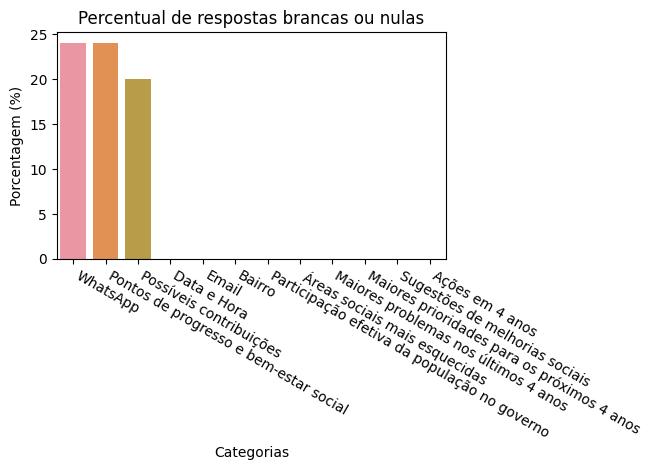

In [8]:
# Porcentagem de respostas sem valor em série
porcentagem_nula = (df_respostas.isna().sum() / df_respostas.shape[0] * 100).round(2).sort_values(ascending=False)

# Ajustar o dataframe
df_nulos = (porcentagem_nula
 .reset_index()
 .rename(columns={'index': 'Categorias', 0: 'Porcentagem (%)'})
)

# # Criar rótulos formatados com o nome da área e sua contagem
# labels = [f'({per})' for per in df_nulos['Porcentagem (%)']]

# Plotando o gráfico de barras 
bar_nulos = sns.barplot(
    x='Categorias', 
    y='Porcentagem (%)', 
    data=df_nulos
)

# Formatando o gráfico
bar_nulos.set(
    title='Percentual de respostas brancas ou nulas', 
    xlabel='Categorias', 
    ylabel='Porcentagem (%)'
)

# # Adicionar rótulos às barras usando ax.bar_label
# for index, row in df_nulos.iterrows():
#     bar_nulos.text(index, row['Porcentagem (%)'] + 1, labels[index], color='black', ha="left", va="top")

plt.xticks(rotation=330, ha='left')
plt.tight_layout()

# Exportar o df
df_nulos.to_csv('data/analises/csv/nulos.csv', index=False)

# Salvando o gráfico em um arquivo PNG
plt.savefig('data/analises/img/nulos.png', format='png')


#### Bairros alcançados

In [9]:
# Todos os 425 bairros de CG | Referência
bairros_cg = pd.read_csv('./data/bruto/bairros_cg.csv')
bairros_cg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 425 entries, 0 to 424
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Bairro  425 non-null    object
 1   CEP     425 non-null    object
dtypes: object(2)
memory usage: 6.8+ KB


In [10]:
# Selecionar a coluna dos bairros alcançados
bairros = df_respostas.iloc[:,3]

# Criar o df
df_bairros = pd.DataFrame(bairros)
df_bairros

,Bairro
0,Noroeste
1,Vila Carvalho
2,Vilas Boas
3,Jardim Petropolis
4,Vila Ipiranga
5,Vila Célia
6,Jockey Club
7,Vila Albuquerque
8,Pioneiros
9,Vila Planalto


In [11]:
# Normalizar e dividir os nomes dos bairros de referência em palavras
bairros_cg['Tokens'] = bairros_cg['Bairro'].str.lower().str.split()
# bairros_cg.drop('Bairro Normalizado', axis=1, inplace=True)
bairros_cg

,Bairro,CEP,Tokens
0,Jardim América,79080-120 à 79080-761,"[jardim, américa]"
1,Jardim Anache,79017-142 à 79017-760,"[jardim, anache]"
2,Jardim Anápolis I,79070-360 à 79070-410,"[jardim, anápolis, i]"
3,Jardim Antáres,79063-301 à 79063-307,"[jardim, antáres]"
4,Jardim Arco Íris,79036-550 à 79036-566,"[jardim, arco, íris]"
...,...,...,...
420,Vila Serradinho,79103-831 à 79104-830,"[vila, serradinho]"
421,Vila Sílvia Regina,79102-260 à 79103-835,"[vila, sílvia, regina]"
422,Vila Taquarussu,79006-050 à 79006-800,"[vila, taquarussu]"
423,Vila Taveirópolis,79090-000 à 79090-170,"[vila, taveirópolis]"


In [12]:
# Função para calcular similaridade
def similaridade(a, b):
    return SequenceMatcher(None, a, b).ratio()

# Função para encontrar bairro mais semelhante
def encontrar_bairro_normalizado(bairro, df_referencia):
    tokens_bairro = set(bairro.lower().split())
    maior_similaridade = 0
    bairro_normalizado = ""
    
    for _, row in df_referencia.iterrows():
        tokens_referencia = set(row['Tokens'])
        intersecao = tokens_bairro & tokens_referencia
        sim = len(intersecao) / len(tokens_referencia)
        
        if sim > maior_similaridade:
            maior_similaridade = sim
            bairro_normalizado = row['Bairro']
    
    return bairro_normalizado


# Aplicar a normalização
df_bairros['Bairro Normalizado'] = df_bairros['Bairro'].apply(
    lambda x: encontrar_bairro_normalizado(x, bairros_cg)
)

df_bairros

,Bairro,Bairro Normalizado
0,Noroeste,Noroeste
1,Vila Carvalho,Vila Carvalho
2,Vilas Boas,Vila Vilas Boas
3,Jardim Petropolis,Jardim América
4,Vila Ipiranga,Vila Ipiranga
5,Vila Célia,Vila Célia
6,Jockey Club,Jardim Jockey Club
7,Vila Albuquerque,Vila Albuquerque
8,Pioneiros,Pioneiros
9,Vila Planalto,Vila Planalto


#### Frequência de respostas por bairro

In [13]:
# Contabilizando a frequência dos bairros correspondentes
df_bairros_freq = (df_bairros['Bairro Normalizado']
                .value_counts()
                .reset_index()
                .rename(columns = {'index': 'Bairro', 'Bairro Normalizado': 'Frequência'})
)

# Plotando o gráfico de barras
# bar_bairros = sns.barplot(
#     x='Bairro', 
#     y='Frequência', 
#     data=df_bairros_freq
# )

# # Formatando o gráfico
# bar_bairros.set(
#     title='Alcance da Pesquisa', 
#     xlabel='Bairros', 
#     ylabel='Frequência'
# )

# # Ajustando a rotação dos rótulos do eixo x, se necessário
# bar_bairros.set_xticklabels(bar_bairros.get_xticklabels(), rotation=45)


# Exportar o df
df_bairros_freq.to_csv('data/analises/csv/bairros_freq.csv', index=False)


#### Respostas afirmativas e negativas diante da participação ativa

In [14]:
df_respostas['Participação efetiva da população no governo']

0     Fundamental 
1              Não
2              Sim
3              Não
4              Não
5              Sim
6              Sim
7              Sim
8              Sim
9              Sim
10             Não
11             Sim
12             Sim
13             Sim
14             Sim
15             Sim
16             Sim
17             Sim
18             Sim
19             Sim
20             Sim
21             Sim
22             Sim
23             Sim
24             Sim
Name: Participação efetiva da população no governo, dtype: object

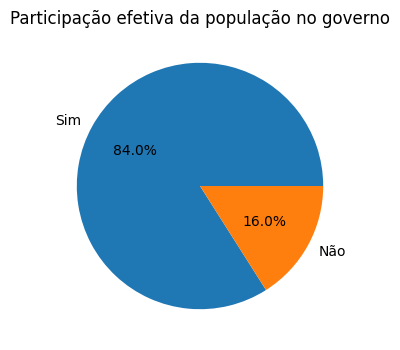

In [15]:
unique_labels = ['Sim', 'Não']

# Contar a ocorrência de cada resposta
participation_counts = (df_respostas['Participação efetiva da população no governo']
    .str.strip().replace('Fundamental', 'Sim')
    .value_counts()
    .plot(
        kind='pie',
        labels=unique_labels,
        figsize=(4, 4),
        autopct='%1.1f%%', # Coloca a porcentagem no gráfico
        title='Participação efetiva da população no governo',
        ylabel=''
    )
)
 
participation_counts;

# Salvando o gráfico em um arquivo PNG
plt.savefig('data/analises/img/participacao_efetiva.png', format='png')


### Análise de Áreas Sociais Esquecidas e Problemas Associados

#### Áreas sociais mais frequentemente esquecidas

In [16]:
# Dataframe das Áreas sociais mais esquecidas e substituição com o nome da categoria correta
df_areas = (df_respostas['Áreas sociais mais esquecidas']
            .str.replace(
                'Proteção ao Portador de Necessidades Especiais',
                'Proteção a Pessoas com Deficiência (Física ou Cognitiva)'
            )
)

df_areas[4]

'Segurança Pública, Desenvolvimento Urbano, Segurança Alimentar, Assistência Social, Proteção a Pessoas com Deficiência (Física ou Cognitiva)'

In [17]:
# Lista das Áreas Sociais
lista_areas = sorted(df_areas
            .str.split(',')
            .explode() # Transforma a lista em uma série
            .str.strip() # Remove espaços em branco
            .unique() # Seleciona os elementos únicos
)

df_areas_sociais = pd.DataFrame({'Áreas Sociais': lista_areas})

# Exportar o df
df_areas_sociais.to_csv('data/analises/csv/areas_sociais.csv', index=False)

In [18]:
# Contagem das áreas sociais mais mencionadas como "esquecidas"
freq_esquecidas = (df_areas
     .str.split(',\s*', expand=True)
     .stack()
     .value_counts()
     .sort_index()
     .reset_index()
     .rename(columns = {'index': 'Área Social', 0: 'Frequência'})
     .sort_values(by=['Frequência'], ascending = False)
     .reset_index(drop=True)
)
freq_esquecidas

,Área Social,Frequência
0,Saúde,21
1,Desenvolvimento Urbano,16
2,Educação,16
3,Segurança Pública,15
4,Segurança Alimentar,13
5,Assistência Social,11
6,Cultura,11
7,Emprego e Renda,10
8,Proteção a Pessoas com Deficiência (Física ou ...,9
9,Proteção à Infância e Juventude,9


#### Gráfico das áreas sociais mais esquecidas

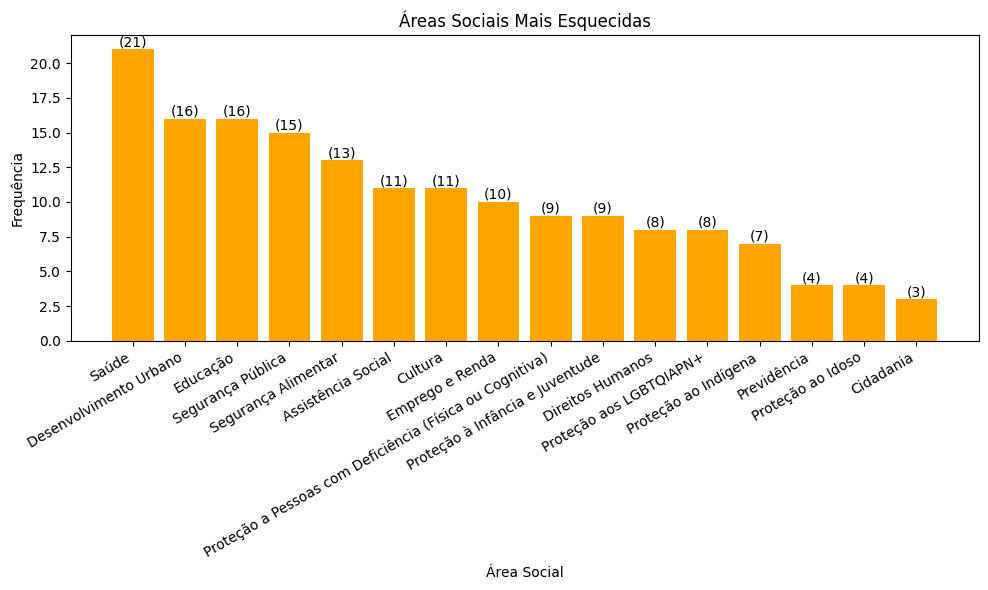

In [19]:
# Criar rótulos formatados com o nome da área e sua contagem
labels = [f'({freq})' for freq in freq_esquecidas['Frequência']]

# Plotar um gráfico de barras usando os dados de df_areas
plt.figure(figsize=(10, 6))

bars = plt.bar(
        freq_esquecidas['Área Social'], 
        freq_esquecidas['Frequência'], 
        color='orange'
    )

# Adicionar rótulos às barras usando bar_label
plt.bar_label(
    bars, 
    labels=labels
)

plt.xlabel('Área Social')
plt.ylabel('Frequência')
plt.title('Áreas Sociais Mais Esquecidas')
plt.xticks(rotation=30, ha='right')
hist = plt.tight_layout()
hist;

# Salvando o gráfico em um arquivo PNG
plt.savefig('data/analises/img/areas_esq.png', format='png')


#### As 5 áreas sociais mais frequentemente esquecidas

In [ ]:
# Selecionar as 5 áreas com maior frequência
top_areas = freq_esquecidas.head()

# Criar rótulos formatados com o nome da área e sua contagem
labels = [f'{area} ({freq})' for area, freq in zip(top_areas['Área Social'], top_areas['Frequência'])]
top_areas

In [ ]:
# Ordenar o DataFrame em ordem decrescente pela coluna 'Frequência'
top_areas = top_areas.sort_values(by='Frequência', ascending=False)

# Plotar um gráfico de pizza usando as áreas selecionadas e suas frequências
plt.figure(figsize=(6, 4))
plt.barh(y=top_areas['Área Social'], width=top_areas['Frequência'])
plt.xlabel('Frequência')
plt.title('As 5 Áreas Sociais Mais Esquecidas')

# Ajustar layout para evitar cortes
plt.tight_layout()

# Salvando o gráfico em um arquivo PNG
plt.savefig('data/analises/img/top_5_esq.png', format='png')


#### Problemas associados por área social

Dentro de cada área social, o que está mais problemático na visão dos moradores de CG?

- Saúde
- Desenvolvimento Urbano
- Educação
- Segurança Pública
- Segurança Alimentar
- Cultura
- Assistência Social
- Emprego e Renda
- Proteção ao Indígena
- Proteção a Pessoas com Deficiência (Física ou Cognitiva)
- Direitos Humanos
- Proteção à Infância e Juventude
- Proteção aos LGBTQIAPN+
- Proteção ao Idoso
- Previdência
- Cidadania

In [ ]:
# Análise por colunas
df_respostas['Áreas sociais mais esquecidas'][24]

In [ ]:
df_respostas['Maiores problemas nos últimos 4 anos'][20]

In [ ]:
df_respostas['Maiores prioridades para os próximos 4 anos'][20]